## Code for selecting ROIs and analyzing all clusters in this ROI

In [5]:
%matplotlib qt
# ---------------------------------------------

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist
import alphashape
import os

# ==========================================
# 1. SETTINGS & FILE PATHS
# ==========================================
FILE_PATH = r"Z:\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\origami cluster.hdf5"
OUTPUT_DIR = r"Z:\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CAMERA_PIXEL_SIZE = 130.0 # nm

# --- FIDUCIAL FILTER SETTINGS ---
MAX_LOCALIZATIONS = 3000       
MAX_ACTIVE_FRAMES = 5000       
MAX_PACKING_DENSITY = 0.25      
# --------------------------------

# ==========================================
# 2. THE SINGLE-CELL INTERACTIVE PICKER
# ==========================================
print("Loading HDF5 data...")
with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]

locs = locs[locs['group'] >= 0]

x_nm = locs['x'] * CAMERA_PIXEL_SIZE
y_nm = locs['y'] * CAMERA_PIXEL_SIZE
groups = locs['group']
frames = locs['frame']

print("\n--- INSTRUCTIONS ---")
print("1. Draw a polygon around your target cell.")
print("2. When finished, CLOSE the window to lock it in.")
print("--------------------\n")

poly_verts = []

def onselect(verts):
    global poly_verts
    poly_verts = verts
    print(f"Polygon captured with {len(verts)} vertices. You can now close the window.")

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(x_nm, y_nm, s=1, alpha=0.1, color='blue')
ax.set_title("Draw ROI around ONE cell. Close window when done.")
ax.set_aspect('equal')
ax.invert_yaxis()

selector = PolygonSelector(ax, onselect)
plt.show(block=True) 

if not poly_verts:
    raise ValueError("No cell was locked in. Execution stopped.")

# ==========================================
# 3. NAME THE CELL & FILTER DATA
# ==========================================
print("\n" + "="*40)
cell_name = input("Enter the save name for this Cell (or press Enter for default 'Cell_1'): ")
if not cell_name.strip():
    cell_name = "Cell_1"

print(f"Processing {cell_name}...")

# Isolate points for this specific cell
poly_path = Path(poly_verts)
points_nm = np.vstack((x_nm, y_nm)).T
mask = poly_path.contains_points(points_nm)

cell_x = x_nm[mask]
cell_y = y_nm[mask]
cell_groups = groups[mask]
cell_frames = frames[mask]
unique_clusters = np.unique(cell_groups)

# Global Cell Math
x_poly, y_poly = zip(*poly_verts)
cell_area_nm2 = 0.5 * np.abs(np.dot(x_poly, np.roll(y_poly, 1)) - np.dot(y_poly, np.roll(x_poly, 1)))
cell_area_um2 = cell_area_nm2 / (1e6) 

results = []
fiducials_removed = 0

# ==========================================
# 4. CLUSTER MATH LOOP & FIDUCIAL REMOVAL
# ==========================================
for cluster_id in unique_clusters:
    idx = (cell_groups == cluster_id)
    pts = np.vstack((cell_x[idx], cell_y[idx])).T
    cluster_frames = cell_frames[idx]
    
    N_locs = len(pts)
    if N_locs < 3:
        continue # Skip mathematically invalid clusters
    
    # --- Frame Analysis ---
    active_frames = len(np.unique(cluster_frames))
    frame_span = int(np.max(cluster_frames) - np.min(cluster_frames))
    
    # PCA for Geometry (Density-weighted)
    cov = np.cov(pts.T)
    evals, evecs = np.linalg.eigh(cov)
    evals = np.sort(evals)[::-1] 
    
    major_axis_nm = 4 * np.sqrt(evals[0]) if evals[0] > 0 else 0
    minor_axis_nm = 4 * np.sqrt(evals[1]) if len(evals) > 1 and evals[1] > 0 else 0
    eccentricity = np.sqrt(1 - (evals[1] / evals[0])) if (evals[0] > 0 and evals[1] > 0) else 0

    # Areas and True Geometric Length (Boundary-weighted)
    try:
        hull = ConvexHull(pts)
        convex_area_nm2 = hull.volume 
        hull_pts = pts[hull.vertices]
        true_length_nm = np.max(pdist(hull_pts))
    except:
        # Fallback if points are perfectly linear and hull calculation fails
        convex_area_nm2 = 0
        true_length_nm = np.max(pdist(pts))
        
    try:
        alpha_shape = alphashape.alphashape(pts, 0.05) 
        alpha_area_nm2 = alpha_shape.area
    except:
        alpha_area_nm2 = convex_area_nm2 

    packing_density = N_locs / alpha_area_nm2 if alpha_area_nm2 > 0 else 0

    # --- FIDUCIAL FILTER EXCLUSION ---
    if (N_locs > MAX_LOCALIZATIONS) or (active_frames > MAX_ACTIVE_FRAMES) or (packing_density > MAX_PACKING_DENSITY):
        fiducials_removed += 1
        continue
    
    results.append({
        "Cluster_ID": cluster_id,
        "N_Localizations": N_locs,
        "Active_Frames": active_frames,
        "Frame_Span": frame_span,
        "PCA_Major_Axis_nm": major_axis_nm,
        "PCA_Minor_Axis_nm": minor_axis_nm,
        "PCA_Eccentricity": eccentricity,
        "True_Geometric_Length_nm": true_length_nm,
        "Convex_Area_nm2": convex_area_nm2,
        "Alpha_Area_nm2": alpha_area_nm2,
        "Packing_Density_locs_per_nm2": packing_density
    })

# Recalculate true structures per um2
valid_structures = len(results)
structures_per_um2 = valid_structures / cell_area_um2 if cell_area_um2 > 0 else 0

print(f" -> Removed {fiducials_removed} suspected fiducials/beads based on frame & density thresholds.")
print(f" -> Analyzed {valid_structures} true biological clusters.")

# ==========================================
# 5. EXPORT & DASHBOARD
# ==========================================
if len(results) == 0:
    print(f"Warning: No valid clusters found in {cell_name}. Skipping plot.")
else:
    df = pd.DataFrame(results)
    
    # Export CSV
    csv_path = os.path.join(OUTPUT_DIR, f"{cell_name}_Stats.csv")
    df.to_csv(csv_path, index=False)
    
    # Generate Dashboard
    fig_dash, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig_dash.canvas.manager.set_window_title(f"Dashboard - {cell_name}")
    fig_dash.suptitle(f"{cell_name} Analytics (Density: {structures_per_um2:.2f} / µm²)", fontsize=16, fontweight='bold')

    # Plot A: Areas
    axes[0, 0].hist(df["Convex_Area_nm2"], bins=30, alpha=0.5, label='Convex', color='royalblue')
    axes[0, 0].hist(df["Alpha_Area_nm2"], bins=30, alpha=0.5, label='Alpha', color='darkorange')
    axes[0, 0].set_title("Area Distribution")
    axes[0, 0].set_xlabel("Area (nm²)")
    axes[0, 0].grid(True, linestyle=':', alpha=0.6)
    axes[0, 0].legend()

    # Plot B: Shapes (True Length vs PCA Eccentricity)
    axes[0, 1].scatter(df["True_Geometric_Length_nm"], df["PCA_Eccentricity"], alpha=0.6, edgecolors='k', color='teal')
    axes[0, 1].set_title("Structural Elongation")
    axes[0, 1].set_xlabel("True Geometric Length (nm)")
    axes[0, 1].set_ylabel("PCA Eccentricity")
    axes[0, 1].grid(True, linestyle=':', alpha=0.6)

    # Plot C: Packing Density
    axes[1, 0].scatter(df["N_Localizations"], df["Packing_Density_locs_per_nm2"], color='green', alpha=0.6, edgecolors='k')
    axes[1, 0].set_title("Protein Packing Density")
    axes[1, 0].set_xlabel("Number of Localizations (N)")
    axes[1, 0].set_ylabel("Density (Locs / nm²)")
    axes[1, 0].grid(True, linestyle=':', alpha=0.6)

    # Plot D: Hollowness
    axes[1, 1].scatter(df["Convex_Area_nm2"], df["Alpha_Area_nm2"], color='purple', alpha=0.6, edgecolors='k')
    
    # Dynamic line for Hollowness
    max_area = df["Convex_Area_nm2"].max()
    axes[1, 1].plot([0, max_area], [0, max_area], '#FF4500', lw=2, linestyle='--', label="Solid (1:1)")
    axes[1, 1].set_title("Hollowness Indicator")
    axes[1, 1].set_xlabel("Convex Area (nm²)")
    axes[1, 1].set_ylabel("Alpha Area (nm²)")
    axes[1, 1].grid(True, linestyle=':', alpha=0.6)
    axes[1, 1].legend()

    plt.tight_layout()
    
    # Save Image
    plot_path = os.path.join(OUTPUT_DIR, f"{cell_name}_Dashboard.png")
    fig_dash.savefig(plot_path, dpi=300)
    
    # Pop up the result window
    fig_dash.show()
    print(f"-> Saved & Displayed: {cell_name}")

Loading HDF5 data...

--- INSTRUCTIONS ---
1. Draw a polygon around your target cell.
2. When finished, CLOSE the window to lock it in.
--------------------

Polygon captured with 5 vertices. You can now close the window.



Enter the save name for this Cell (or press Enter for default 'Cell_1'):  origami


Processing origami...
 -> Removed 137 suspected fiducials/beads based on frame & density thresholds.
 -> Analyzed 3298 true biological clusters.
-> Saved & Displayed: origami


 ## Code for comparing cluster results by pathways

--- Setup Comparison ---


Enter the name for Group 1 (e.g., 'Control'):  Apoptosis
Enter the name for Group 2 (e.g., 'Apoptosis' or 'Pyroptosis'):  Pyroptosis



Waiting for file selection...
-> Step 1: Select all Apoptosis cell CSV files.
-> Step 2: Select all Pyroptosis cell CSV files.

Successfully loaded valid clusters:
 - Apoptosis: 457 clusters
 - Pyroptosis: 460 clusters

--- STATISTICAL RESULTS (Mann-Whitney U Test) ---
Alpha_Area_nm2: p-value = 7.7474e-34 [***]
Eccentricity: p-value = 3.8886e-08 [***]
Packing_Density_locs_per_nm2: p-value = 8.3957e-103 [***]
N_Localizations: p-value = 5.1190e-09 [***]


C:\Users\47936\AppData\Local\Temp\ipykernel_22488\4294048004.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\47936\AppData\Local\Temp\ipykernel_22488\4294048004.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\47936\AppData\Local\Temp\ipykernel_22488\4294048004.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\47936\AppData\Local\Temp\ipykernel_22488\4294048004.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v


Figure successfully saved to: Z:\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Stats_Apoptosis_vs_Pyroptosis.png


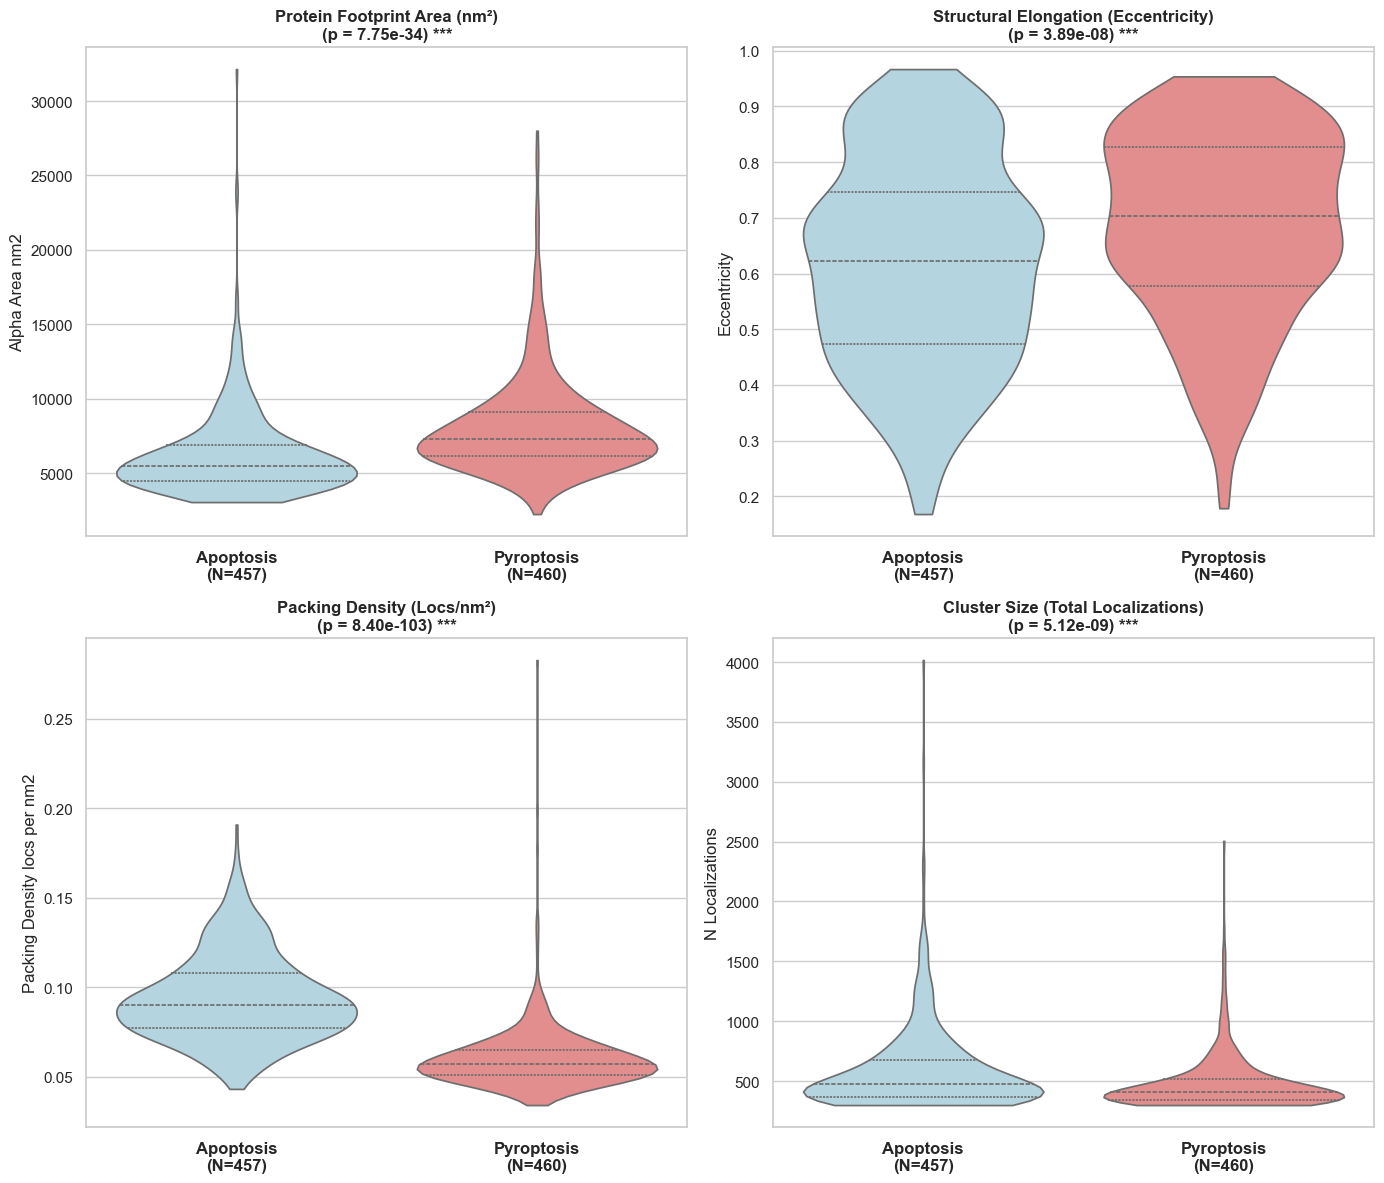

In [9]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import tkinter as tk
from tkinter import filedialog
import os

# ==========================================
# 1. SETTINGS & CUSTOM GROUPS
# ==========================================
OUTPUT_DIR = r"Z:\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_LOCALIZATIONS = 6000   
MAX_PACKING_DENSITY = 0.5  

# Ask the user for the names of the two groups being compared
print("--- Setup Comparison ---")
group1_name = input("Enter the name for Group 1 (e.g., 'Control'): ") or "Control"
group2_name = input("Enter the name for Group 2 (e.g., 'Apoptosis' or 'Pyroptosis'): ") or "Experimental"

# ==========================================
# 2. FILE SELECTION UI
# ==========================================
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True) 

print(f"\nWaiting for file selection...")
print(f"-> Step 1: Select all {group1_name} cell CSV files.")
group1_files = filedialog.askopenfilenames(title=f"Select {group1_name} CSVs", filetypes=[("CSV Files", "*.csv")])

print(f"-> Step 2: Select all {group2_name} cell CSV files.")
group2_files = filedialog.askopenfilenames(title=f"Select {group2_name} CSVs", filetypes=[("CSV Files", "*.csv")])

root.destroy()

if not group1_files or not group2_files:
    raise ValueError("Missing files. You must select at least one file for both groups.")

# ==========================================
# 3. DATA MERGING & QUALITY CONTROL
# ==========================================
df_list = []

for file in group1_files:
    temp_df = pd.read_csv(file)
    temp_df['Condition'] = group1_name
    df_list.append(temp_df)

for file in group2_files:
    temp_df = pd.read_csv(file)
    temp_df['Condition'] = group2_name
    df_list.append(temp_df)

master_df = pd.concat(df_list, ignore_index=True)
initial_count = len(master_df)

# Apply Fiducial / Outlier Filters
master_df = master_df[
    (master_df['N_Localizations'] <= MAX_LOCALIZATIONS) & 
    (master_df['Packing_Density_locs_per_nm2'] <= MAX_PACKING_DENSITY)
]

# Calculate final N values for the labels
counts = master_df['Condition'].value_counts()
n1 = counts.get(group1_name, 0)
n2 = counts.get(group2_name, 0)

print(f"\nSuccessfully loaded valid clusters:")
print(f" - {group1_name}: {n1} clusters")
print(f" - {group2_name}: {n2} clusters")

# ==========================================
# 4. STATISTICAL TESTING & VISUALIZATION
# ==========================================
metrics = [
    "Alpha_Area_nm2", 
    "Eccentricity", 
    "Packing_Density_locs_per_nm2", 
    "N_Localizations"
]

titles = [
    "Protein Footprint Area (nm²)", 
    "Structural Elongation (Eccentricity)", 
    "Packing Density (Locs/nm²)", 
    "Cluster Size (Total Localizations)"
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

palette = {group1_name: "lightblue", group2_name: "lightcoral"}

print("\n--- STATISTICAL RESULTS (Mann-Whitney U Test) ---")

for i, metric in enumerate(metrics):
    data1 = master_df[master_df['Condition'] == group1_name][metric].dropna()
    data2 = master_df[master_df['Condition'] == group2_name][metric].dropna()
    
    stat, p_value = mannwhitneyu(data1, data2, alternative='two-sided')
    
    if p_value < 0.001: sig = "***"
    elif p_value < 0.01: sig = "**"
    elif p_value < 0.05: sig = "*"
    else: sig = "ns"
        
    print(f"{metric}: p-value = {p_value:.4e} [{sig}]")
    
    ax = axes[i]
    sns.violinplot(
        data=master_df, x="Condition", y=metric, 
        ax=ax, palette=palette, inner="quartile",
        cut=0
    )
    
    # Add Title with Stats
    ax.set_title(f"{titles[i]}\n(p = {p_value:.2e}) {sig}", fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel(metric.replace("_", " "))
    
    # --- THE FIX: ADD 'N' TO THE X-AXIS LABELS ---
    # Automatically appends \n(N=150) to the bottom of the violin plot categories
    new_labels = [f"{group1_name}\n(N={n1})", f"{group2_name}\n(N={n2})"]
    ax.set_xticks([0, 1])
    ax.set_xticklabels(new_labels, fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the figure dynamically based on your group names
save_path = os.path.join(OUTPUT_DIR, f"Stats_{group1_name}_vs_{group2_name}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nFigure successfully saved to: {save_path}")

plt.show()

## Code for aggregating cell by cell results

-> Select CSVs for: Control


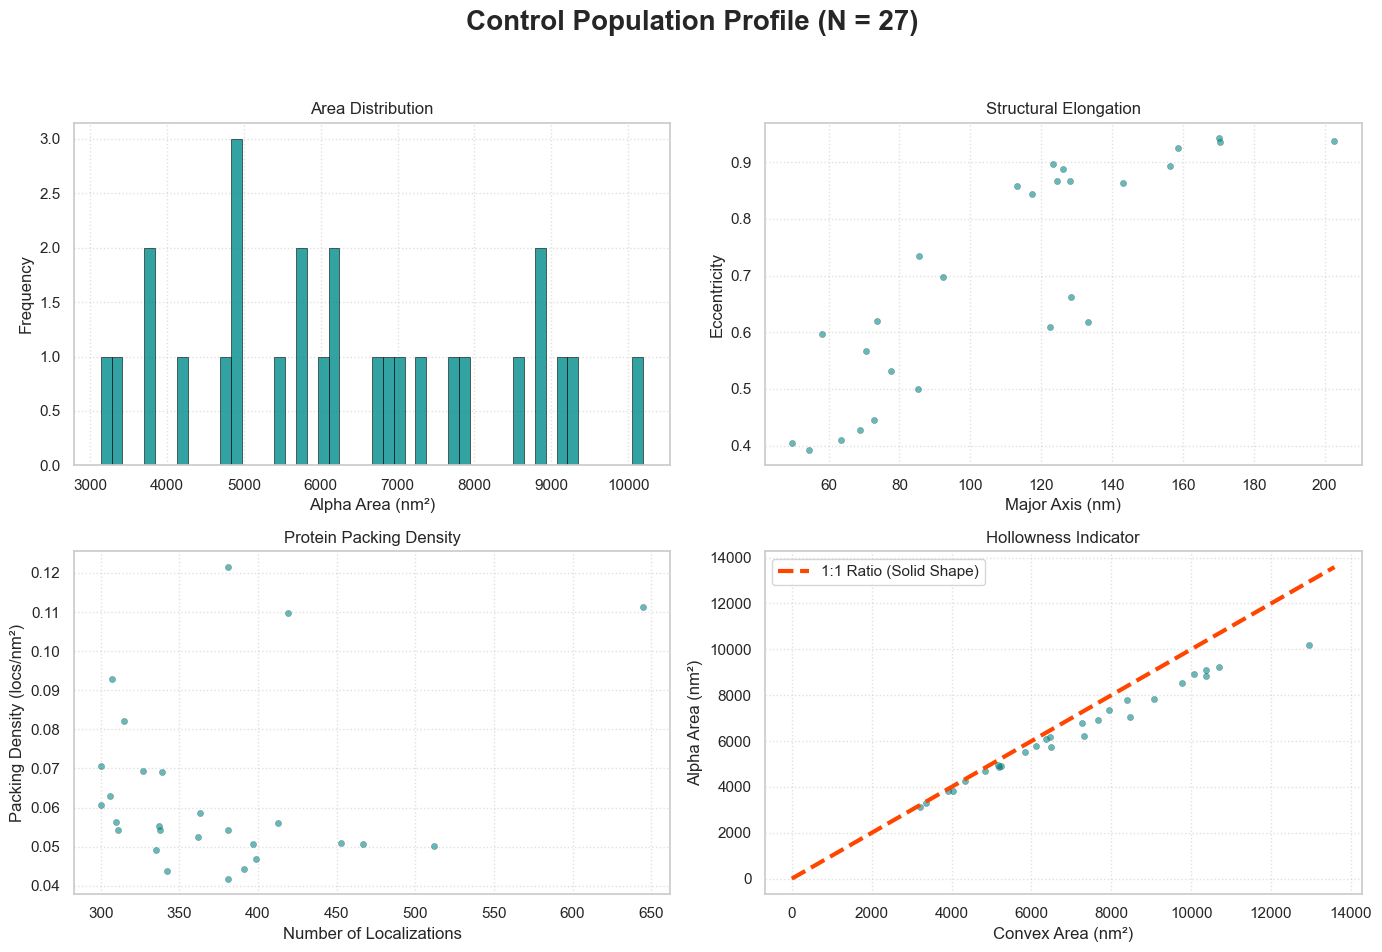

-> Select CSVs for: Apoptosis


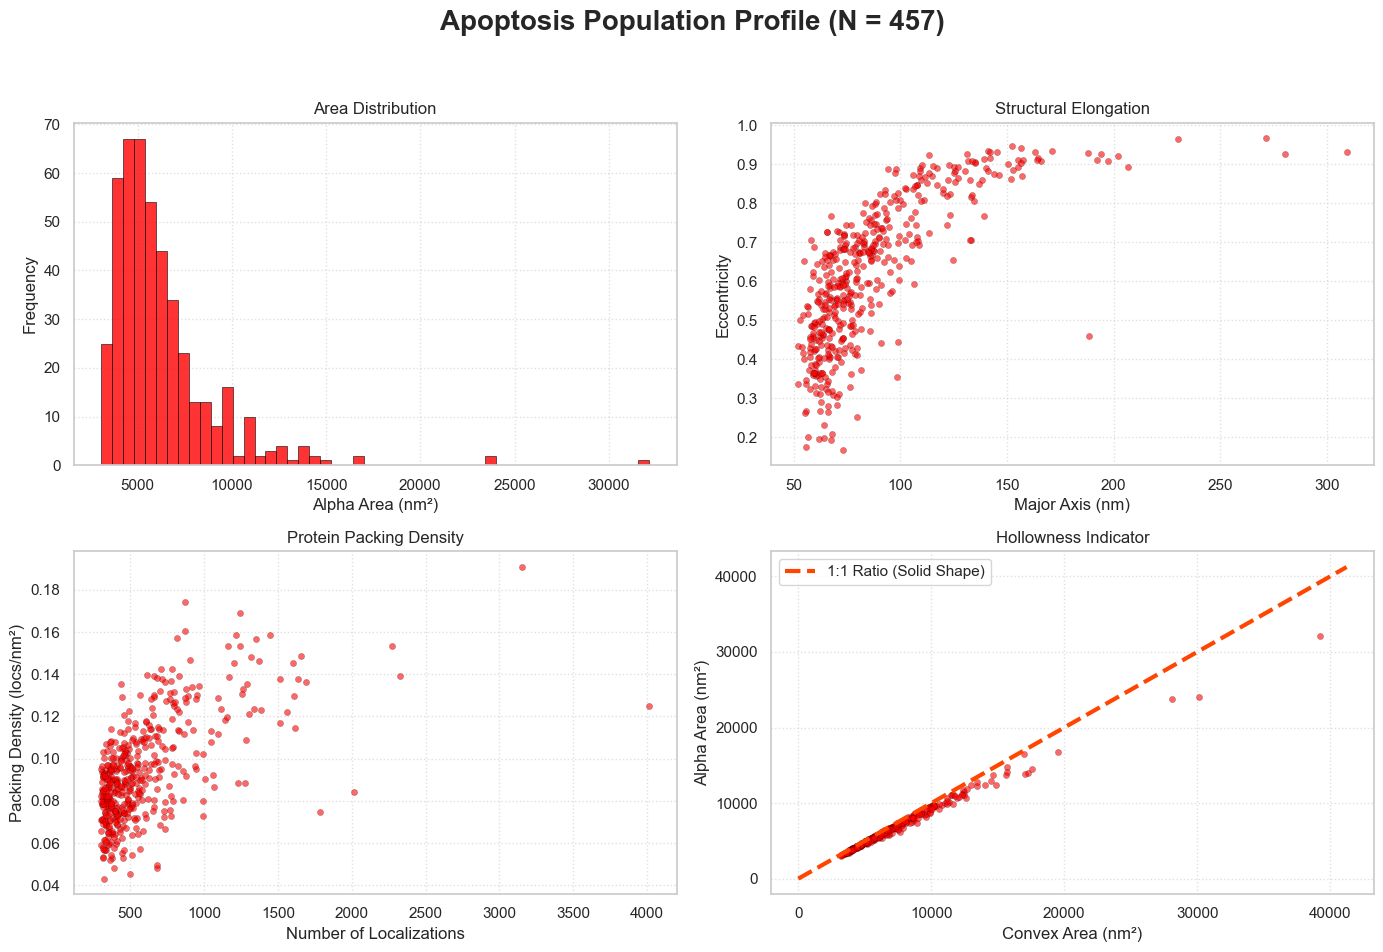

-> Select CSVs for: Pyroptosis


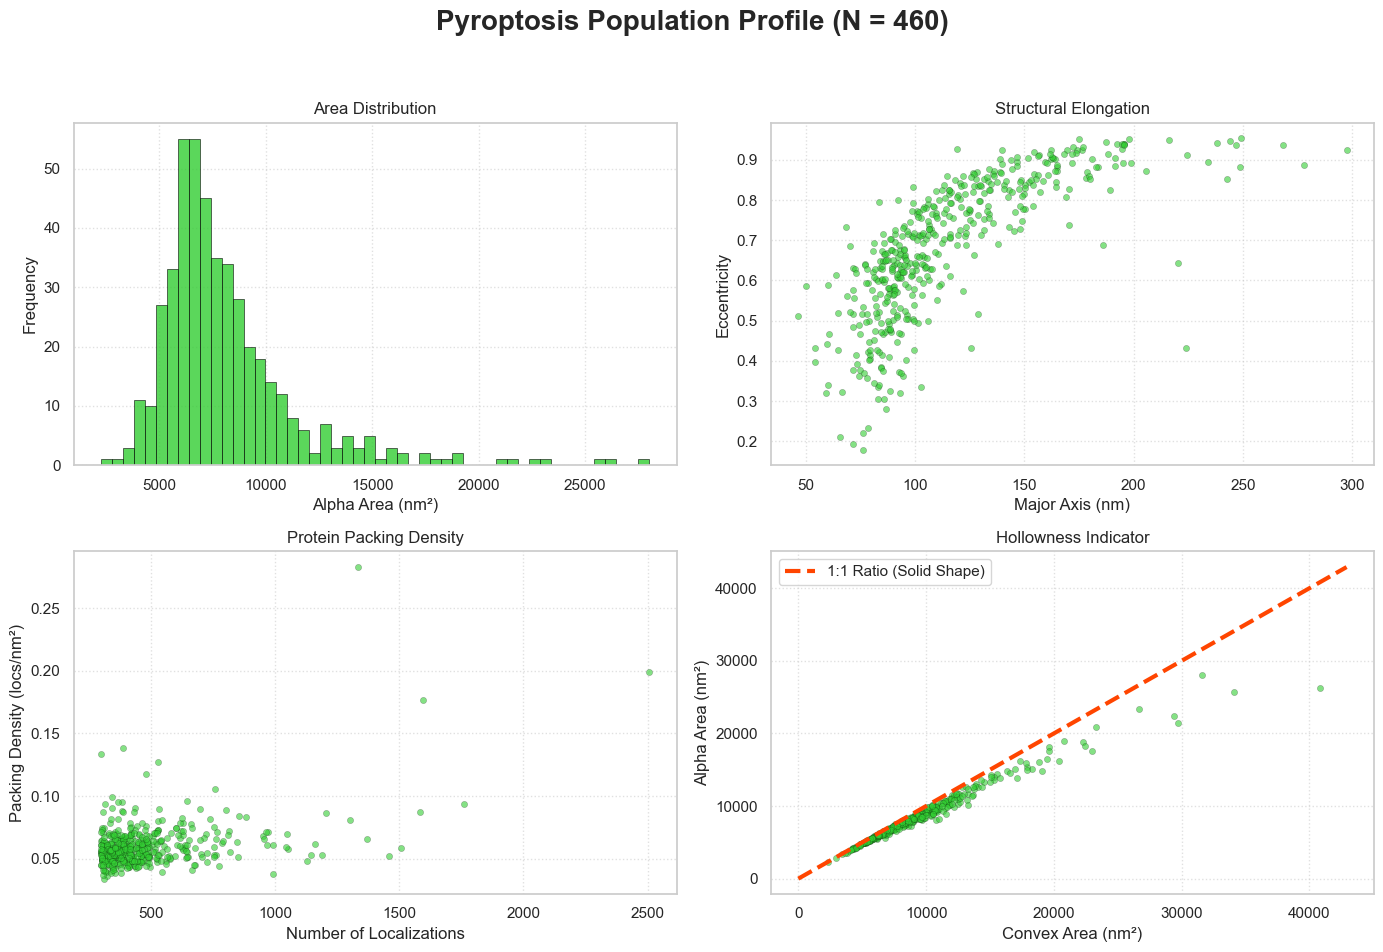

Done! All cumulative dashboards saved.


In [22]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import os

# ==========================================
# 1. SETTINGS
# ==========================================
OUTPUT_DIR = r"Z:\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Cumulative"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CONDITIONS = ["Control", "Apoptosis", "Pyroptosis"]

# Hide background window
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True) 

# ==========================================
# 2. PLOTTING LOOP
# ==========================================
COLOR_MAP = {"Control": "#008B8B", "Apoptosis": "#FF0000", "Pyroptosis": "#32CD32"}

for condition in CONDITIONS:
    print(f"-> Select CSVs for: {condition}")
    file_paths = filedialog.askopenfilenames(title=f"Select all {condition} CSVs", filetypes=[("CSV Files", "*.csv")])
    if not file_paths: continue
    
    df = pd.concat([pd.read_csv(f) for f in file_paths], ignore_index=True)
    current_color = COLOR_MAP.get(condition, "royalblue")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{condition} Population Profile (N = {len(df)})", fontsize=20, fontweight='bold')

    # A: Areas (Dynamic Auto-scaling)
    axes[0, 0].hist(df["Alpha_Area_nm2"], bins=50, alpha=0.8, color=current_color, edgecolor='black', linewidth=0.5)
    axes[0, 0].set_title("Area Distribution")
    axes[0, 0].set_xlabel("Alpha Area (nm²)")
    axes[0, 0].set_ylabel("Frequency")
    axes[0, 0].grid(True, linestyle=':', alpha=0.6)
    
    # B: Shapes (Dynamic Auto-scaling)
    axes[0, 1].scatter(df["Major_Axis_nm"], df["Eccentricity"], alpha=0.6, s=20, color=current_color, edgecolors='black', linewidth=0.2)
    axes[0, 1].set_title("Structural Elongation")
    axes[0, 1].set_xlabel("Major Axis (nm)")
    axes[0, 1].set_ylabel("Eccentricity")
    axes[0, 1].grid(True, linestyle=':', alpha=0.6)
    
    # C: Packing Density (Dynamic Auto-scaling)
    axes[1, 0].scatter(df["N_Localizations"], df["Packing_Density_locs_per_nm2"], alpha=0.6, s=20, color=current_color, edgecolors='black', linewidth=0.2)
    axes[1, 0].set_title("Protein Packing Density")
    axes[1, 0].set_xlabel("Number of Localizations")
    axes[1, 0].set_ylabel("Packing Density (locs/nm²)")
    axes[1, 0].grid(True, linestyle=':', alpha=0.6)
    
    # D: Hollowness (Dynamic Auto-scaling with dynamic 1:1 line)
    axes[1, 1].scatter(df["Convex_Area_nm2"], df["Alpha_Area_nm2"], alpha=0.6, s=20, color=current_color, edgecolors='black', linewidth=0.2)
    
    # Calculate dynamic max for the 1:1 reference line
    max_area = max(df["Convex_Area_nm2"].max(), df["Alpha_Area_nm2"].max())
    line_max = max_area * 1.05 # Adds a 5% buffer so the line reaches the edge perfectly
    
    axes[1, 1].plot([0, line_max], [0, line_max], '#FF4500', lw=3, linestyle='--', label='1:1 Ratio (Solid Shape)')
    axes[1, 1].set_title("Hollowness Indicator")
    axes[1, 1].set_xlabel("Convex Area (nm²)")
    axes[1, 1].set_ylabel("Alpha Area (nm²)")
    axes[1, 1].legend(loc="upper left")
    axes[1, 1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(OUTPUT_DIR, f"Cumulative_{condition}_FINAL.png"), dpi=300)
    plt.show()

root.destroy()
print("Done! All cumulative dashboards saved.")

## Code for showing example clusters

In [ ]:
# %matplotlib qt

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull, cKDTree
import alphashape
import warnings
import tkinter as tk
from tkinter import filedialog
import random

warnings.filterwarnings("ignore", category=UserWarning)

# ==========================================
# 1. SETTINGS
# ==========================================
FILE_PATH = r"Z:\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\origami cluster.hdf5"
CAMERA_PIXEL_SIZE = 130.0   # nm
MIN_LOCALIZATIONS = 30      
TOP_N = 6                   

# Initialize tkinter for the save dialog
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

# ==========================================
# 2. LOAD & ITERATE DATA
# ==========================================
print("Loading HDF5 data and calculating geometries...")
with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]

# Filter out unclustered noise
locs = locs[locs['group'] >= 0]

# Coordinates converted to nanometers
x_all = locs['x'] * CAMERA_PIXEL_SIZE
y_all = locs['y'] * CAMERA_PIXEL_SIZE
groups_all = locs['group']

unique_clusters = np.unique(groups_all)
candidates = []

for cluster_id in unique_clusters:
    idx = (groups_all == cluster_id)
    pts = np.vstack((x_all[idx], y_all[idx])).T
    
    if len(pts) < MIN_LOCALIZATIONS:
        continue
        
    # ==========================================
    # THE FIX: CORE POINT EXTRACTION
    # ==========================================
    # Use a KDTree to find the distance to the 5th nearest neighbor for every point
    tree = cKDTree(pts)
    dists, _ = tree.query(pts, k=5)
    local_density = dists[:, -1] # Distance to the 5th neighbor
    
    # Keep the 90% most densely packed points, rejecting the 10% sparse halo
    density_threshold = np.percentile(local_density, 90)
    core_mask = local_density <= density_threshold
    
    core_pts = pts[core_mask]
    halo_pts = pts[~core_mask]
    
    # Skip if the filtering left too few points to form a polygon
    if len(core_pts) < 10:
        continue

    # ==========================================
    # GEOMETRY (CALCULATED ONLY ON CORE)
    # ==========================================
    try:
        hull = ConvexHull(core_pts) 
        convex_area = hull.volume 
    except:
        continue 
        
    try:
        alpha_poly = alphashape.alphashape(core_pts, 0.05)
        alpha_area = alpha_poly.area
    except:
        alpha_area = convex_area 
        
    if alpha_area <= 0:
        continue
        
    hollowness_ratio = convex_area / alpha_area
    
    if 200 < convex_area < 2000:
        candidates.append({
            'cluster_id': cluster_id,
            'pts': pts,
            'core_pts': core_pts,
            'halo_pts': halo_pts,
            'convex_area': convex_area,
            'alpha_area': alpha_area,
            'hollowness_ratio': hollowness_ratio,
            'hull': hull,
            'alpha_poly': alpha_poly
        })

# ==========================================
# 3. SELECT RANDOM UNBIASED CANDIDATES
# ==========================================
if len(candidates) == 0:
    print("No valid single origami candidates found in this file.")
else:
    if len(candidates) >= TOP_N:
        top_candidates = random.sample(candidates, TOP_N)
    else:
        top_candidates = candidates
        
    print(f"Plotting a random sample of {len(top_candidates)} properly sized DNA Origami Structures.")

    max_range = 0
    for cand in top_candidates:
        pts = cand['pts']
        x_range = pts[:, 0].max() - pts[:, 0].min()
        y_range = pts[:, 1].max() - pts[:, 1].min()
        max_range = max(max_range, x_range, y_range)

    # Add 150 nm of guaranteed empty space
    window_size = max_range + 150 

    # ==========================================
    # 4. GRID PLOTTING
    # ==========================================
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.canvas.manager.set_window_title("Random Sample: DNA Origami Structures (Core Analyzed)")
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i >= len(top_candidates):
            ax.axis('off')
            continue
            
        cand = top_candidates[i]
        core_pts = cand['core_pts']
        halo_pts = cand['halo_pts']
        hull = cand['hull']
        alpha_poly = cand['alpha_poly']
        
        # 1. Plot Halo Points (Faint Gray)
        ax.scatter(halo_pts[:, 0], halo_pts[:, 1], s=10, alpha=0.2, color='gray', edgecolors='none', label='Rejected Halo')
        
        # 2. Plot Core Points (Solid Blue)
        ax.scatter(core_pts[:, 0], core_pts[:, 1], s=10, alpha=0.8, color='royalblue', edgecolors='none', label='Dense Core')
        
        # 3. Plot Convex Hull (Wrapped around Core)
        for simplex in hull.simplices:
            ax.plot(core_pts[simplex, 0], core_pts[simplex, 1], 'k--', lw=1.5)
            
        # 4. Plot Alpha Shape (Wrapped around Core)
        if alpha_poly is not None:
            if alpha_poly.geom_type == 'Polygon':
                x, y = alpha_poly.exterior.xy
                ax.plot(x, y, color='darkorange', linestyle='-', linewidth=2)
            elif alpha_poly.geom_type == 'MultiPolygon':
                for geom in alpha_poly.geoms:
                    x, y = geom.exterior.xy
                    ax.plot(x, y, color='darkorange', linestyle='-', linewidth=2)

        # 5. Lock Proportions and Invert Y-Axis
        cx = core_pts[:, 0].mean()
        cy = core_pts[:, 1].mean()
        
        ax.set_xlim(cx - window_size/2, cx + window_size/2)
        ax.set_ylim(cy + window_size/2, cy - window_size/2)
        
        ax.set_aspect('equal')
        ax.axis('off')
        
        # 6. Place Scalebar
        x_min, x_max = ax.get_xlim()
        y_max, y_min = ax.get_ylim()
        
        bar_x = x_min + 0.05 * window_size
        bar_y = y_max - 0.05 * window_size 
        
        ax.plot([bar_x, bar_x + 100], [bar_y, bar_y], color='black', linewidth=4)
        
        text_y = bar_y - 0.04 * window_size
        ax.text(bar_x + 50, text_y, '100 nm', 
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
        
        # Clean Title
        title_text = (f"Cluster {cand['cluster_id']}\n"
                      f"Area: {cand['convex_area']:.0f} nm² | Ratio: {cand['hollowness_ratio']:.2f}")
        ax.set_title(title_text, fontsize=11, fontweight='bold')

    plt.tight_layout()

    # ==========================================
    # 5. SAVE & DISPLAY
    # ==========================================
    save_path = filedialog.asksaveasfilename(
        title="Save Figure As",
        defaultextension=".png",
        filetypes=[("PNG Image", "*.png"), ("PDF Document", "*.pdf"), ("SVG Graphics", "*.svg"), ("All Files", "*.*")]
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure successfully saved to: {save_path}")
    else:
        print("Save cancelled. Displaying figure only.")

    plt.show()

# Clean up tkinter
root.destroy()

## EXTRA code below

In [41]:
%matplotlib qt

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import alphashape

# ==========================================
# 1. SETTINGS
# ==========================================
FILE_PATH = r"Z:\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\origami cluster.hdf5"
TARGET_CLUSTER = 314          #  Type your cluster number you want to see here
CAMERA_PIXEL_SIZE = 130.0   # nm

# ==========================================
# 2. LOAD & FILTER DATA
# ==========================================
with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]

# Filter down to just the one cluster
cluster_locs = locs[locs['group'] == TARGET_CLUSTER]

if len(cluster_locs) == 0:
    print(f"Error: Cluster {TARGET_CLUSTER} not found in this file.")
else:
    # Convert to real-world nanometers
    x_nm = cluster_locs['x'] * CAMERA_PIXEL_SIZE
    y_nm = cluster_locs['y'] * CAMERA_PIXEL_SIZE
    pts = np.vstack((x_nm, y_nm)).T
    
    # Calculate geometric center 
    center_x, center_y = np.mean(x_nm), np.mean(y_nm)

    # ==========================================
    # 3. MATH FOR VISUALIZATIONS
    # ==========================================
    # A. Convex Hull
    hull = None
    if len(pts) >= 3:
        hull = ConvexHull(pts)

    # B. Alpha Shape (Concave Hull)
    alpha_poly = None
    try:
        alpha_poly = alphashape.alphashape(pts, 0.05)
    except Exception as e:
        print("Warning: Could not calculate Alpha Shape.", e)

    # C. PCA (Major and Minor Axes)
    cov = np.cov(pts.T)
    evals, evecs = np.linalg.eigh(cov)
    # Sort eigenvalues descending (Largest first = Major Axis)
    sort_indices = np.argsort(evals)[::-1]
    evals = evals[sort_indices]
    evecs = evecs[:, sort_indices]

    # Calculate the radius of each axis 
    # (Using 2*sqrt(eval) to match the 4*sqrt(eval) total length from our analytics)
    major_radius = 2 * np.sqrt(evals[0])
    minor_radius = 2 * np.sqrt(evals[1]) if evals[1] > 0 else 0

    # Calculate the start and end coordinates of the vector lines
    major_p1 = [center_x - major_radius * evecs[0, 0], center_y - major_radius * evecs[1, 0]]
    major_p2 = [center_x + major_radius * evecs[0, 0], center_y + major_radius * evecs[1, 0]]
    
    minor_p1 = [center_x - minor_radius * evecs[0, 1], center_y - minor_radius * evecs[1, 1]]
    minor_p2 = [center_x + minor_radius * evecs[0, 1], center_y + minor_radius * evecs[1, 1]]

    # ==========================================
    # 4. HIGH-RES PLOTTING
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 10))
    fig.canvas.manager.set_window_title(f"High-Res Viewer: Cluster {TARGET_CLUSTER}")
    
    # Plot 1: Raw Localizations
    ax.scatter(x_nm, y_nm, s=15, alpha=0.5, color='royalblue', edgecolors='none', label='Localizations')
    
    # Plot 2: Center Point
    ax.plot(center_x, center_y, 'X', color='black', markersize=8, label='Centroid')

    # Plot 3: Convex Hull (Outer Boundary)
    if hull is not None:
        for i, simplex in enumerate(hull.simplices):
            ax.plot(pts[simplex, 0], pts[simplex, 1], 'k--', lw=1.5, label='Convex Hull' if i == 0 else "")

    # Plot 4: Alpha Shape (Inner/Concave Boundary)
    if alpha_poly is not None:
        # Alphashape returns 'shapely' objects, which can be single or multi-polygons
        if alpha_poly.geom_type == 'Polygon':
            x, y = alpha_poly.exterior.xy
            ax.plot(x, y, color='darkorange', linestyle='-', linewidth=2.5, label='Alpha Shape')
        elif alpha_poly.geom_type == 'MultiPolygon':
            for i, geom in enumerate(alpha_poly.geoms):
                x, y = geom.exterior.xy
                ax.plot(x, y, color='darkorange', linestyle='-', linewidth=2.5, label='Alpha Shape' if i == 0 else "")

    # Plot 5: Major and Minor Axes
    ax.plot([major_p1[0], major_p2[0]], [major_p1[1], major_p2[1]], color='red', linewidth=3, label=f'Major Axis ({major_radius*2:.1f} nm)')
    ax.plot([minor_p1[0], minor_p2[0]], [minor_p1[1], minor_p2[1]], color='green', linewidth=3, label=f'Minor Axis ({minor_radius*2:.1f} nm)')

    # Format the Canvas
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(f"NINJ1 Cluster {TARGET_CLUSTER} Geometry Analysis", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (nm)", fontsize=12)
    ax.set_ylabel("Y (nm)", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Place Legend
    ax.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()
    print(f"Successfully rendered all geometric properties for Cluster {TARGET_CLUSTER}.")

Successfully rendered all geometric properties for Cluster 314.


Loading HDF5 data...

--- INSTRUCTIONS ---
1. Draw a polygon around your target cell.
2. When finished, CLOSE the window to lock it in.
--------------------

Polygon captured with 8 vertices. You can now close the window.



Enter the save name for this Cell (or press Enter for default 'Cell_1'):  origami_2


Processing origami_2...
 -> Removed 0 suspected fiducials/beads based on frame & density thresholds.
 -> Analyzed 524 true biological clusters.
-> Saved & Displayed: origami_2


Loading HDF5 data and calculating geometries...


## Code for DRAQ7 Intensity over time per cell

-> Please select your DRAQ7 text files...


C:\Users\47936\AppData\Local\Temp\ipykernel_14380\1007211943.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(v, m)


Processed 0h.txt -> Time: 0.0h | Cells: 1 | Intensity/Cell: 35.21
Processed 1h.txt -> Time: 1.0h | Cells: 1 | Intensity/Cell: 30.06
Processed 2h.txt -> Time: 2.0h | Cells: 6 | Intensity/Cell: 47.50
Processed 3h.txt -> Time: 3.0h | Cells: 7 | Intensity/Cell: 41.07
Processed 4h.txt -> Time: 4.0h | Cells: 3 | Intensity/Cell: 50.42

Figure successfully saved to: Z:/cmic_konfokal/richarja/DRAQ intensity/DRAQ7_Timecourse_Plot_june.png


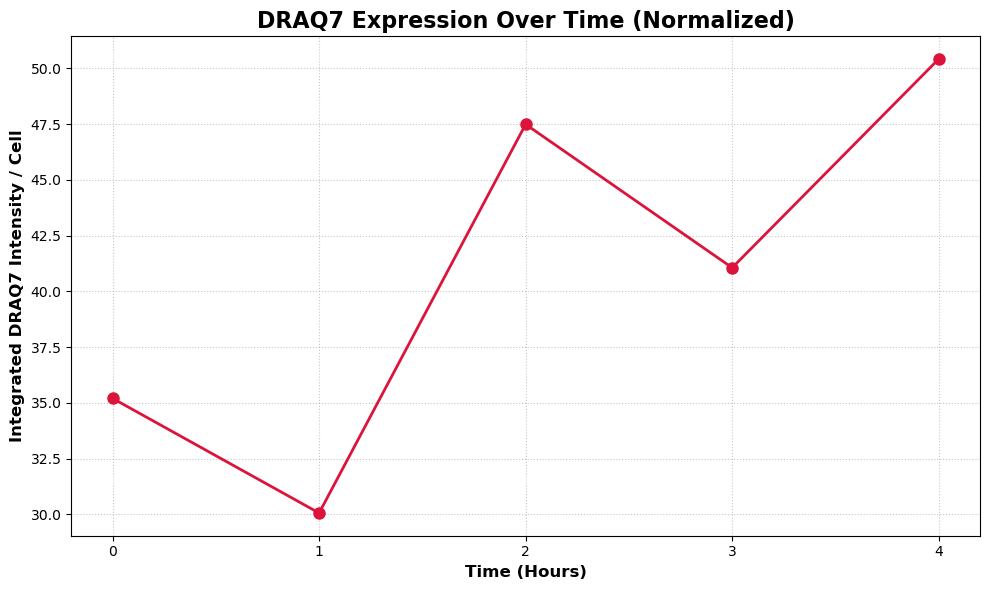

In [13]:

# %matplotlib qt

import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog, simpledialog
import os

def parse_and_integrate_intensity(filepath):
    """
    Parses the text file into separate blocks and calculates the total 
    integrated intensity (Area Under the Curve) across all blocks.
    """
    blocks = []
    current_micron = []
    current_mean = []
    
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                try:
                    m = float(parts[0])
                    v = float(parts[1])
                    current_micron.append(m)
                    current_mean.append(v)
                except ValueError:
                    # This hits when it reads the "[micron] Mean" header
                    if current_micron:
                        blocks.append((current_micron, current_mean))
                        current_micron = []
                        current_mean = []
                        
        # Append the final block if the file ends
        if current_micron:
            blocks.append((current_micron, current_mean))
            
    # Calculate Area Under the Curve for each block to account for varying step sizes
    total_integrated_intensity = 0.0
    for m, v in blocks:
        # np.trapz integrates the 'y' values (Mean) along the 'x' spacing (micron)
        area = np.trapz(v, m)
        total_integrated_intensity += area
        
    return total_integrated_intensity

def main():
    # Hide the main background tkinter window
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("-> Please select your DRAQ7 text files...")
    file_paths = filedialog.askopenfilenames(
        title="Select DRAQ7 Intensity Files",
        filetypes=[("Text Files", "*.txt"), ("All Files", "*.*")]
    )
    
    if not file_paths:
        print("No files selected. Exiting.")
        root.destroy()
        return

    data_points = []

    # Loop through each selected file and prompt the user for input
    for filepath in file_paths:
        filename = os.path.basename(filepath)
        
        # 1. Ask for the Timepoint
        time_val = simpledialog.askfloat(
            "Input Timepoint", 
            f"File: {filename}\n\nEnter the timepoint (e.g., 0, 1, 2, 3, 4):",
            parent=root
        )
        if time_val is None:
            print(f"Skipped {filename}.")
            continue
            
        # 2. Ask for the Cell Count
        cells_val = simpledialog.askinteger(
            "Input Cell Count", 
            f"File: {filename}\nTime: {time_val}h\n\nEnter the number of DRAQ7 expressing cells:",
            parent=root
        )
        if cells_val is None or cells_val <= 0:
            print(f"Invalid cell count for {filename}. Skipped.")
            continue

        # 3. Process the file
        total_intensity = parse_and_integrate_intensity(filepath)
        intensity_per_cell = total_intensity / cells_val
        
        data_points.append({
            'time': time_val,
            'intensity_per_cell': intensity_per_cell
        })
        
        print(f"Processed {filename} -> Time: {time_val}h | Cells: {cells_val} | Intensity/Cell: {intensity_per_cell:.2f}")

    if not data_points:
        print("No valid data points collected.")
        root.destroy()
        return

    # Sort data by time so the line graph draws chronologically from left to right
    data_points.sort(key=lambda x: x['time'])
    
    times = [pt['time'] for pt in data_points]
    intensities = [pt['intensity_per_cell'] for pt in data_points]

    # ==========================================
    # PLOTTING
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    plt.plot(times, intensities, marker='o', markersize=8, color='crimson', linewidth=2, linestyle='-')
    
    plt.title("DRAQ7 Expression Over Time (Normalized)", fontsize=16, fontweight='bold')
    plt.xlabel("Time (Hours)", fontsize=12, fontweight='bold')
    plt.ylabel("Integrated DRAQ7 Intensity / Cell", fontsize=12, fontweight='bold')
    
    # Set x-ticks to strictly match the timepoints provided
    plt.xticks(times)
    
    # Grid for easier reading
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()

    # ==========================================
    # SAVE & DISPLAY
    # ==========================================
    save_path = filedialog.asksaveasfilename(
        title="Save Plot As",
        defaultextension=".png",
        filetypes=[("PNG Image", "*.png"), ("PDF Document", "*.pdf"), ("SVG Graphics", "*.svg"), ("All Files", "*.*")],
        parent=root
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nFigure successfully saved to: {save_path}")
    else:
        print("\nSave cancelled. Displaying figure only.")

    # Destroy the tkinter root before showing the plot to avoid hanging windows
    root.destroy()

    plt.show()

if __name__ == "__main__":
    main()